# Segmentación de Votantes en España con K-Means

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · No Supervisado · Clustering · K-Means

---

### Objetivo

Aplicar **K-Means** para segmentar a 3.689 votantes españoles en función de sus características demográficas y opiniones políticas, y descubrir si existen perfiles diferenciados que se correspondan con los principales partidos.

### Contexto

Tengo un dataset con información demográfica y opiniones políticas de votantes que declaran su voto a PP, PSOE o VOX. En lugar de usar el voto como variable objetivo (eso sería clasificación supervisada), voy a **ignorar el voto durante el clustering** y dejar que el algoritmo descubra los grupos por sí mismo. Después compararé los clusters resultantes con el voto real para ver si K-Means captura patrones reales.

## 1. Setup: librerías y configuración visual

In [1]:
# Librerías base
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Preprocesamiento y modelado
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND    = '#fbfbfb'
PURPLE        = '#7a7bff'   # único color de énfasis / serie única en scatter y líneas (1 por gráfico)
PURPLE_LIGHT  = '#9b9cff'   # EDA de una sola serie (histogramas independientes)
POSITIVE      = '#6b8158'   # exclusivo signo positivo
NEGATIVE      = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR   = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE  = '#8f8c9e'   # líneas de contexto
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ líneas de contexto
INK           = '#111111'
MUTED         = '#707070'

# Paleta categórica para identidad de cluster — validada (ΔE OKLab, simulación CVD) para
# pares adyacentes (barras, líneas, enlaces de dendrograma). En scatter/PCA con 4+ clusters
# el color por sí solo no basta para daltonismo severo: por eso cada cluster lleva también
# una forma de marcador distinta (CLUSTER_MARKERS) — nunca dependas solo del color.
CLUSTER_PALETTE = ['#7a7bff', '#eb6834', '#1baf7a', '#e34948', '#eda100', '#e87ba4', '#008300']
CLUSTER_MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X']

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga de datos

In [2]:
data = pd.read_excel("politicos.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head(10)

Registros: 3689 | Columnas: 9


,edad,ingresos,estudios,estado_civil,seguridad,impuestos,servicios_publicos,inmigracion,voto
0,61,1690,Postgraduate,Married,3,9,2,1,PP
1,26,1978,Basic,Divorced,1,5,9,1,PSOE
2,68,1547,Postgraduate,Widowed,9,9,10,2,PP
3,31,2937,University,Married,2,4,10,9,PSOE
4,43,2639,University,Divorced,7,1,1,9,VOX
5,55,4536,Postgraduate,Married,7,2,9,3,PSOE
6,37,3684,Postgraduate,Widowed,3,2,6,3,PP
7,27,1062,Postgraduate,Divorced,2,6,9,7,PP
8,62,4134,Postgraduate,Widowed,8,4,8,10,VOX
9,58,4504,Basic,Married,5,7,2,3,PP


## 3. Análisis Exploratorio

In [3]:
data.describe().round(2)

,edad,ingresos,seguridad,impuestos,servicios_publicos,inmigracion
count,3689.00,3689.00,3689.00,3689.00,3689.00,3689.00
mean,48.66,3015.00,5.61,5.55,5.53,5.49
std,18.14,1157.47,2.87,2.85,2.89,2.90
min,18.00,1000.00,1.00,1.00,1.00,1.00
25%,33.00,2023.00,3.00,3.00,3.00,3.00
50%,48.00,2999.00,6.00,6.00,5.00,5.00
75%,64.00,4022.00,8.00,8.00,8.00,8.00
max,80.00,5000.00,10.00,10.00,10.00,10.00


In [4]:
print('TIPOS DE DATOS Y VALORES NULOS')
print('─' * 70)
info = pd.DataFrame({
    'Tipo': data.dtypes,
    'Nulos': data.isnull().sum(),
    '% Nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'Únicos': data.nunique()
})
info

TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
edad,int64,0,0.0,63
ingresos,int64,0,0.0,2432
estudios,object,0,0.0,3
estado_civil,object,0,0.0,4
seguridad,int64,0,0.0,10
impuestos,int64,0,0.0,10
servicios_publicos,int64,0,0.0,10
inmigracion,int64,0,0.0,10
voto,object,0,0.0,3


### Distribución del voto

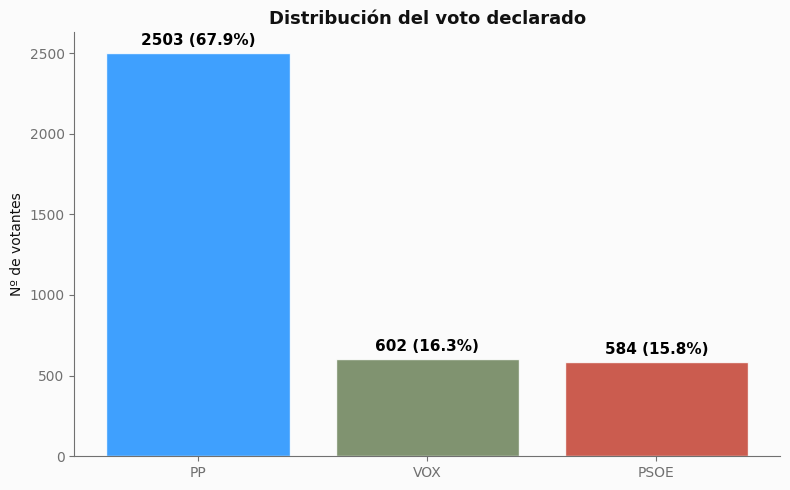

Distribución:
  PP: 2503 votantes (67.9%)
  VOX: 602 votantes (16.3%)
  PSOE: 584 votantes (15.8%)


In [5]:
voto_counts = data['voto'].value_counts()
voto_pct = data['voto'].value_counts(normalize=True)

colores_partido = {'PP': '#1E90FF', 'PSOE': NEGATIVE, 'VOX': POSITIVE}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(voto_counts.index, voto_counts.values,
              color=[colores_partido[p] for p in voto_counts.index],
              edgecolor='white', alpha=0.85)

for bar, v, pct in zip(bars, voto_counts.values, voto_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{v} ({pct:.1%})', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribución del voto declarado', fontsize=13, fontweight='bold')
ax.set_ylabel('Nº de votantes')
plt.tight_layout()
plt.show()

print("Distribución:")
for partido in voto_counts.index:
    print(f"  {partido}: {voto_counts[partido]} votantes ({voto_pct[partido]:.1%})")

El dataset está **desbalanceado**: PP concentra el 67.8% de los votantes, mientras que PSOE y VOX representan ~16% cada uno.

### Distribución de las variables de opinión

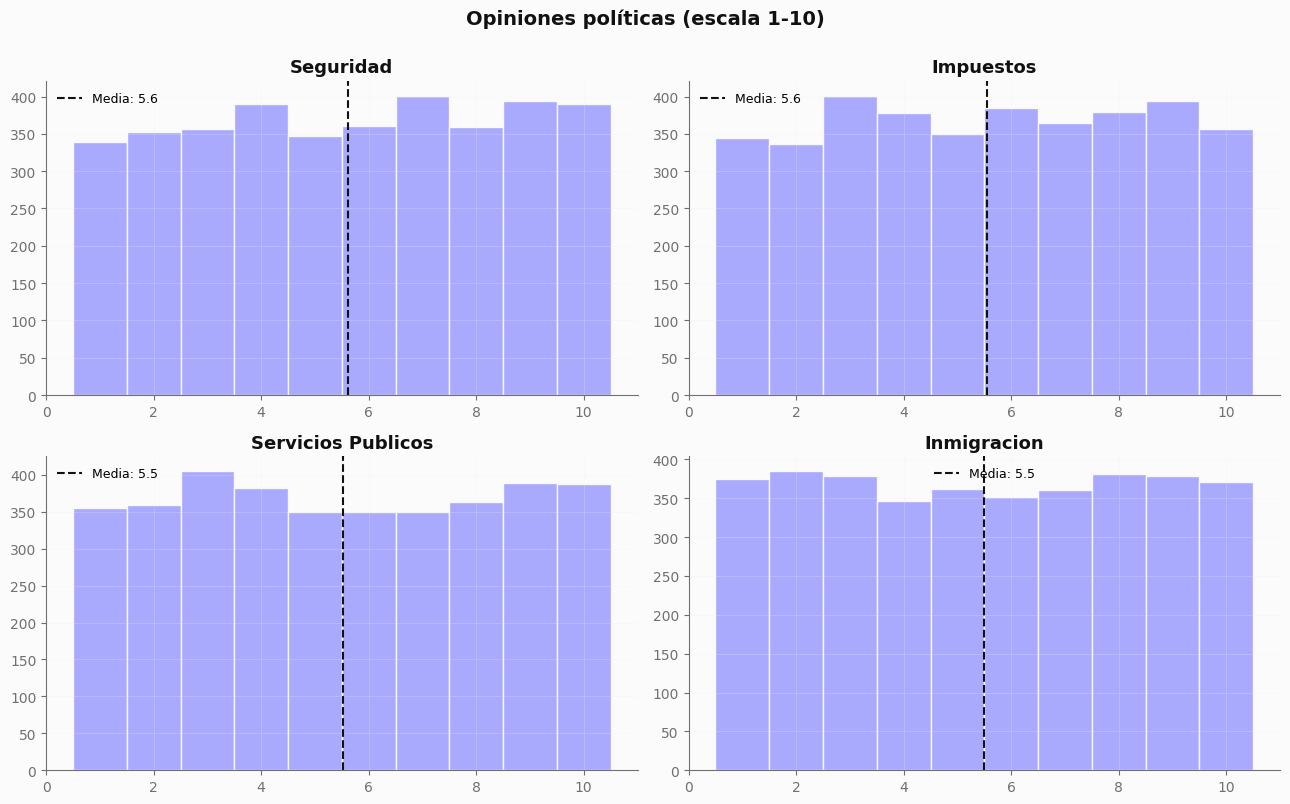

In [6]:
opinion_cols = ['seguridad', 'impuestos', 'servicios_publicos', 'inmigracion']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Opiniones políticas (escala 1-10)', fontsize=14, fontweight='bold', color=INK, y=1.00)

for ax, var in zip(axes.flat, opinion_cols):
    ax.hist(data[var], bins=10, color=PURPLE_LIGHT, edgecolor='white', alpha=0.85, range=(0.5, 10.5))
    ax.axvline(data[var].mean(), color=INK, linestyle='--', linewidth=1.5,
               label=f'Media: {data[var].mean():.1f}')
    ax.set_title(var.replace('_', ' ').title(), color=INK)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Las cuatro variables de opinión presentan distribuciones **prácticamente uniformes** (media ~5.5, sin sesgo claro).

### Opiniones medias por partido

Opiniones medias por partido:
      seguridad  impuestos  servicios_publicos  inmigracion
voto                                                       
PP         5.06       6.12                4.76         4.91
PSOE       5.05       3.14                8.60         4.89
VOX        8.45       5.53                5.71         8.52



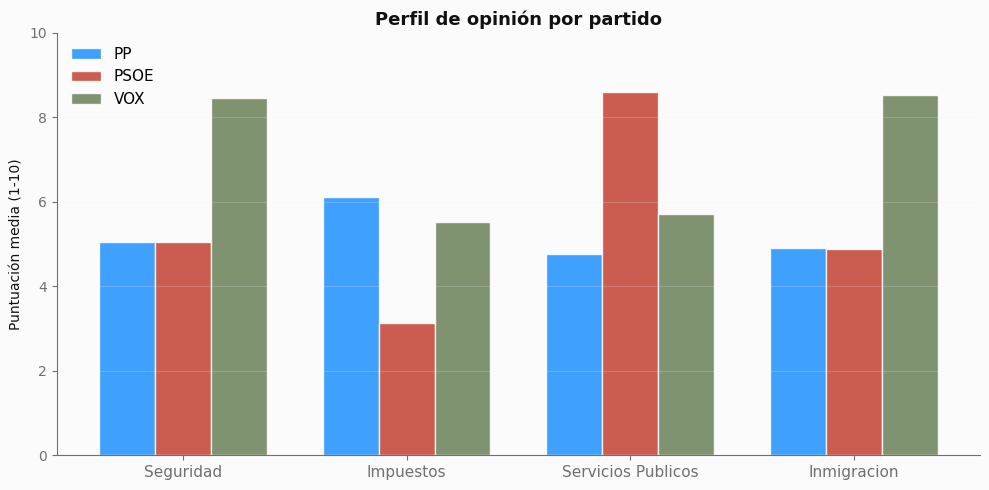

In [7]:
perfil_partido = data.groupby('voto')[opinion_cols].mean().round(2)
print("Opiniones medias por partido:")
print(perfil_partido.to_string())
print()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(opinion_cols))
width = 0.25

for i, (partido, color) in enumerate(colores_partido.items()):
    if partido in perfil_partido.index:
        vals = perfil_partido.loc[partido].values
        ax.bar(x + i*width, vals, width, label=partido, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels([c.replace('_', ' ').title() for c in opinion_cols], fontsize=11)
ax.set_ylabel('Puntuación media (1-10)')
ax.set_title('Perfil de opinión por partido', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=11)
ax.set_ylim(0, 10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

- **VOX** destaca en **seguridad** (8.45) e **inmigración** (8.52).
- **PSOE** destaca en **servicios públicos** (8.60) y tiene la puntuación más baja en **impuestos** (3.14).
- **PP** muestra un perfil intermedio, con la puntuación más alta en **impuestos** (6.12).

La pregunta es: ¿será K-Means capaz de descubrir estos perfiles sin conocer el voto?

### Matriz de correlación

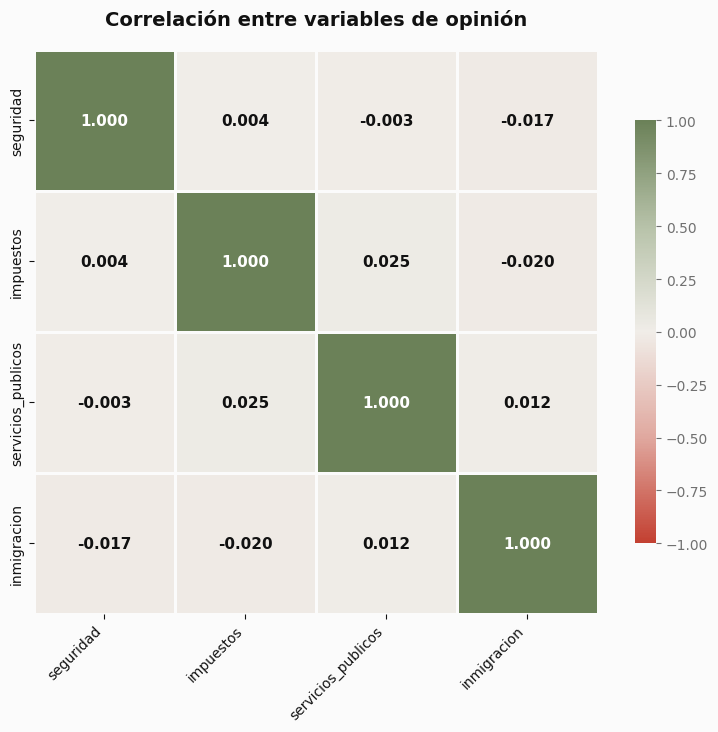

In [8]:
corr = data[opinion_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".3f", cmap=DIVERGING_CMAP, center=0, vmin=-1, vmax=1,
            square=True, linewidths=2, linecolor=BACKGROUND, cbar_kws={"shrink": 0.75},
            annot_kws={"size": 11, "weight": "bold"})
color_annotations(ax, corr.values, threshold=0.8)
ax.set_title("Correlación entre variables de opinión", fontsize=14, fontweight="bold", color=INK, pad=18)
ax.tick_params(colors=INK)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Las correlaciones entre las cuatro variables de opinión son **prácticamente nulas** (todas < 0.03). Cada variable aporta información independiente.

## 4. Preprocesamiento

### 4.1 Encoding de variables categóricas

Las variables `estudios` y `estado_civil` son categóricas nominales(no tienen orden jerárquico). Si las dejase como texto, K-Means no podría procesarlas. Y si usara Label Encoding (asignar 0, 1, 2), estaría creando una distancia artificial entre categorías que no existe (¿"University" está a distancia 2 de "Basic"?).

Por eso utilizo **One-Hot Encoding** con `drop='first'` para evitar multicolinealidad: cada categoría se convierte en una columna binaria (0/1).

In [9]:
# One-Hot Encoding
cat_cols = ['estudios', 'estado_civil']
ohe = OneHotEncoder(drop='first', sparse_output=False)
cat_encoded = ohe.fit_transform(data[cat_cols])
cat_names = ohe.get_feature_names_out(cat_cols)

print("Variables categóricas originales:")
for c in cat_cols:
    print(f"  {c}: {sorted(data[c].unique())}")

print(f"\nColumnas tras One-Hot Encoding (drop='first'):")
for name in cat_names:
    print(f"  {name}")

print(f"\nShape datos codificados: {cat_encoded.shape}")

Variables categóricas originales:
  estudios: ['Basic', 'Postgraduate', 'University']
  estado_civil: ['Divorced', 'Married', 'Single', 'Widowed']

Columnas tras One-Hot Encoding (drop='first'):
  estudios_Postgraduate
  estudios_University
  estado_civil_Married
  estado_civil_Single
  estado_civil_Widowed

Shape datos codificados: (3689, 5)


### 4.2 Construcción de la matriz de features

Combino todas las variables numéricas: las 4 de opinión + edad + ingresos + las 5 columnas codificadas del One-Hot = **11 features** en total.

In [10]:
# Construir matriz completa
opinion_cols = ['seguridad', 'impuestos', 'servicios_publicos', 'inmigracion']
num_cols = ['edad', 'ingresos']

X = pd.concat([
    data[opinion_cols + num_cols].reset_index(drop=True),
    pd.DataFrame(cat_encoded, columns=cat_names)
], axis=1)

print(f"Matriz de features: {X.shape[0]} registros × {X.shape[1]} variables")
print(f"\nColumnas: {list(X.columns)}")

Matriz de features: 3689 registros × 11 variables

Columnas: ['seguridad', 'impuestos', 'servicios_publicos', 'inmigracion', 'edad', 'ingresos', 'estudios_Postgraduate', 'estudios_University', 'estado_civil_Married', 'estado_civil_Single', 'estado_civil_Widowed']


### 4.3 Estandarización

K-Means utiliza distancias euclídeas, por lo que todas las variables deben estar en la misma escala. Sin estandarizar, `ingresos` (rango ~1.000-5.000) dominaría sobre `seguridad` (rango 1-10).

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Verificación del escalado:")
print(f"  Medias:  {X_scaled.mean(axis=0).round(4)}")
print(f"  Std:     {X_scaled.std(axis=0).round(4)}")

Verificación del escalado:
  Medias:  [-0.  0.  0. -0. -0. -0. -0. -0.  0.  0. -0.]
  Std:     [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Selección del número de clusters

Utilizo dos métodos complementarios:

- **Método del Codo:** busca el punto donde añadir más clusters deja de reducir significativamente la inercia.
- **Silhouette Score:** mide qué tan bien asignado está cada punto a su cluster.

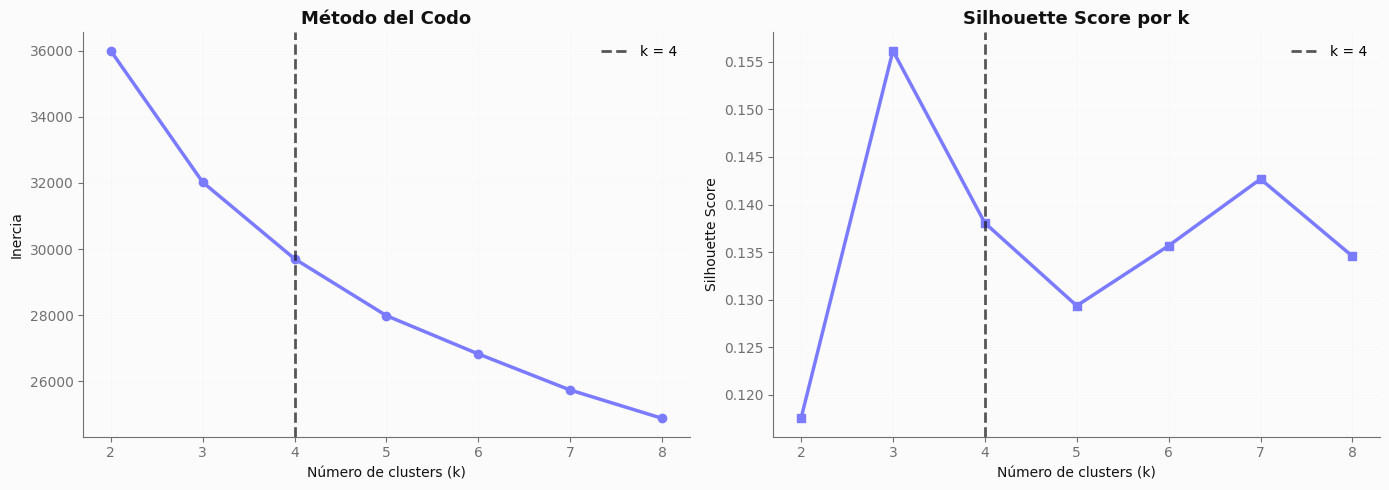

Detalle por k:
  k=2: inercia=35995.9 | silhouette=0.1175
  k=3: inercia=32023.9 | silhouette=0.1562
  k=4: inercia=29706.8 | silhouette=0.1381 ← elegido
  k=5: inercia=27988.0 | silhouette=0.1294
  k=6: inercia=26829.8 | silhouette=0.1357
  k=7: inercia=25739.2 | silhouette=0.1427
  k=8: inercia=24884.1 | silhouette=0.1346


In [12]:
K_range = range(2, 9)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Mejor k por silhouette
best_k = list(K_range)[np.argmax(silhouettes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_range), inertias, marker='o', color=PURPLE, linewidth=2.5)
ax1.axvline(x=4, color=INK, linestyle='--', linewidth=2, alpha=0.7, label='k = 4')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo', fontsize=13, fontweight='bold')
ax1.set_xticks(list(K_range))
ax1.legend(frameon=False)
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_range), silhouettes, marker='s', color=PURPLE, linewidth=2.5)
ax2.axvline(x=4, color=INK, linestyle='--', linewidth=2, alpha=0.7, label='k = 4')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por k', fontsize=13, fontweight='bold')
ax2.set_xticks(list(K_range))
ax2.legend(frameon=False)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Detalle por k:")
for k, iner, sil in zip(K_range, inertias, silhouettes):
    marker = " ← elegido" if k == 4 else ""
    print(f"  k={k}: inercia={iner:.1f} | silhouette={sil:.4f}{marker}")

### Decisión: k = 4

- El codo de la curva de inercia se marca alrededor de k=4.
- El silhouette score con k=4 es 0.138 — bajo, lo que indica clusters con cierto solapamiento. Esto es esperable en datos de opinión donde las fronteras ideológicas no son nítidas.
- Elijo k=4 porque tiene sentido analítico: el espectro político español tiene más matices que solo 3 partidos.

## 6. Modelo K-Means (k = 4)

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Silhouette Score: {silhouette_score(X_scaled, data['cluster']):.4f}")
print(f"\nDistribución de clusters:")
for cl in range(4):
    n = (data['cluster'] == cl).sum()
    print(f"  Cluster {cl}: {n} votantes ({n/len(data)*100:.1f}%)")

Silhouette Score: 0.1381

Distribución de clusters:
  Cluster 0: 1269 votantes (34.4%)
  Cluster 1: 869 votantes (23.6%)
  Cluster 2: 918 votantes (24.9%)
  Cluster 3: 633 votantes (17.2%)


## 7. Perfiles de los clusters

### Opiniones por cluster

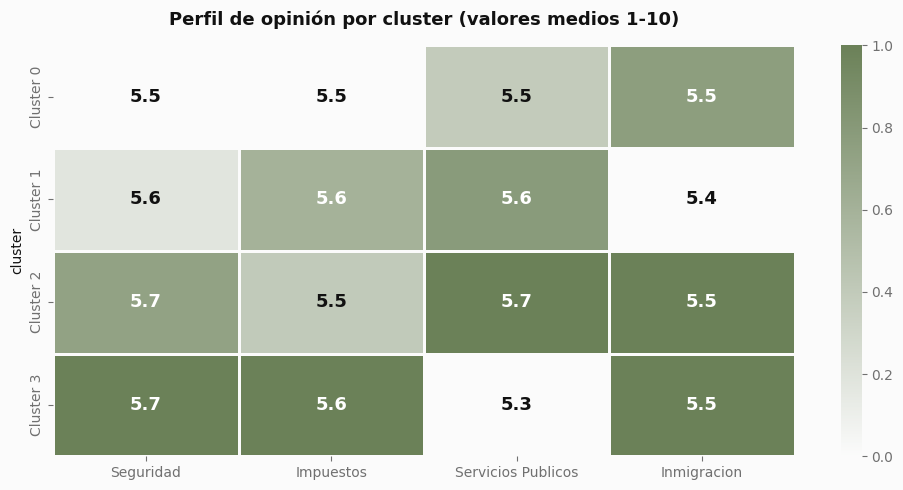

Perfil numérico:
         seguridad  impuestos  servicios_publicos  inmigracion
cluster                                                       
0             5.52       5.49                5.47         5.51
1             5.56       5.58                5.60         5.38
2             5.68       5.55                5.67         5.55
3             5.74       5.64                5.34         5.55


In [14]:
# Perfil medio de opiniones por cluster
perfil = data.groupby('cluster')[opinion_cols].mean().round(2)

perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(perfil_norm, annot=perfil.values, fmt='.1f', cmap=SEQUENTIAL_GREEN,
            linewidths=1, linecolor=BACKGROUND, ax=ax,
            xticklabels=[c.replace('_', ' ').title() for c in opinion_cols],
            yticklabels=[f'Cluster {i}' for i in range(4)],
            annot_kws={'size': 13, 'weight': 'bold'})
color_annotations(ax, perfil_norm.values, threshold=0.6)
ax.set_title('Perfil de opinión por cluster (valores medios 1-10)',
             fontsize=13, fontweight='bold', color=INK, pad=15)
plt.tight_layout()
plt.show()

print("Perfil numérico:")
print(perfil.to_string())

### Clusters vs. Voto real

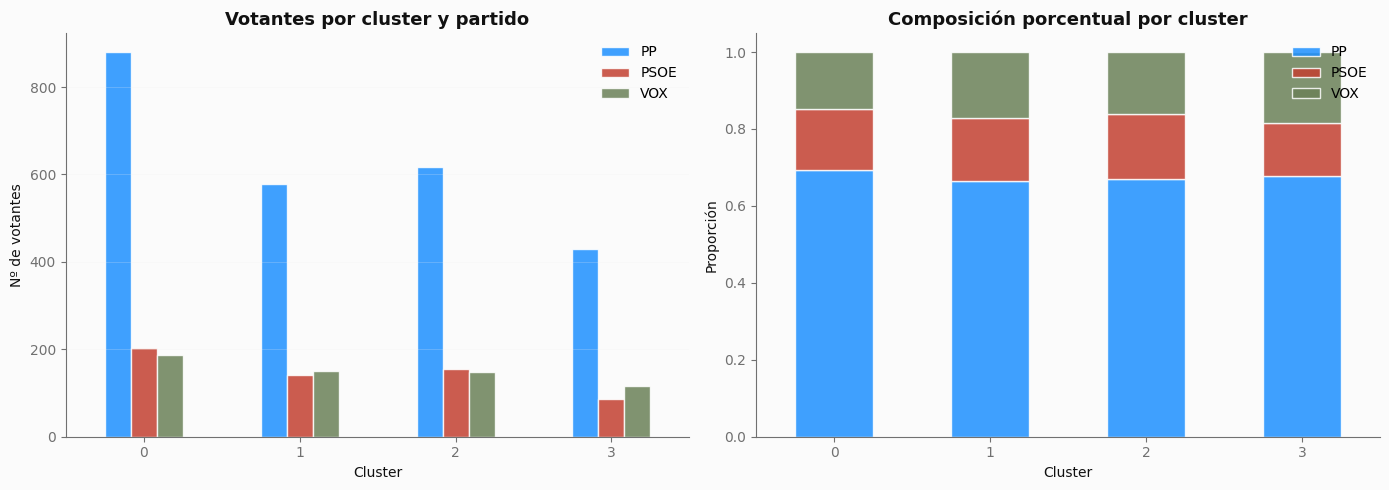

Composición de cada cluster (%):
voto       PP  PSOE   VOX
cluster                  
0        69.3  15.9  14.7
1        66.5  16.2  17.3
2        67.1  16.8  16.1
3        67.8  13.7  18.5


In [15]:
ct = pd.crosstab(data['cluster'], data['voto'])
ct_pct = pd.crosstab(data['cluster'], data['voto'], normalize='index')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ct.plot(kind='bar', ax=ax1, color=[colores_partido[p] for p in ct.columns],
        edgecolor='white', alpha=0.85)
ax1.set_title('Votantes por cluster y partido', fontsize=13, fontweight='bold')
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Nº de votantes')
ax1.legend(frameon=False)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.grid(True, alpha=0.3, axis='y')

ct_pct.plot(kind='bar', stacked=True, ax=ax2,
            color=[colores_partido[p] for p in ct_pct.columns],
            edgecolor='white', alpha=0.85)
ax2.set_title('Composición porcentual por cluster', fontsize=13, fontweight='bold')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Proporción')
ax2.legend(frameon=False)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("Composición de cada cluster (%):")
print((ct_pct * 100).round(1).to_string())

### Demografía por cluster

In [16]:
demo = data.groupby('cluster')[['edad', 'ingresos']].agg(['mean', 'std']).round(1)
print("Demografía por cluster:")
print(demo.to_string())

print("\nEstudios por cluster (%):")
print((pd.crosstab(data['cluster'], data['estudios'], normalize='index') * 100).round(1).to_string())

print("\nEstado civil por cluster (%):")
print((pd.crosstab(data['cluster'], data['estado_civil'], normalize='index') * 100).round(1).to_string())

Demografía por cluster:
         edad       ingresos        
         mean   std     mean     std
cluster                             
0        49.2  17.7   3029.2  1159.1
1        48.3  18.4   3000.1  1140.1
2        48.2  18.2   3026.5  1183.0
3        48.9  18.6   2990.2  1142.5

Estudios por cluster (%):
estudios  Basic  Postgraduate  University
cluster                                  
0          53.0           0.0        47.0
1          29.3          37.1        33.6
2          37.1          32.2        30.6
3           0.0         100.0         0.0

Estado civil por cluster (%):
estado_civil  Divorced  Married  Single  Widowed
cluster                                         
0                 51.1     48.9     0.0      0.0
1                  0.0      0.0     0.0    100.0
2                  0.0      0.0   100.0      0.0
3                 52.1     47.9     0.0      0.0


### Lectura de los perfiles

**Cluster 0 (34.4%):** Mezcla de nivel de estudios Basic y University, con estado civil Divorced y Married. Las opiniones políticas están en la media (~5.5 en todas). Composición de voto: 69% PP, 16% PSOE, 15% VOX.

**Cluster 1 (17.2%):** 100% viudos/as (Widowed) con estudios variados. Opiniones cercanas a la media. Composición de voto: 67% PP, 16% PSOE, 17% VOX.

**Cluster 2 (24.9%):** 100% solteros/as (Single) con estudios variados. Opiniones cercanas a la media. Composición de voto: 67% PP, 17% PSOE, 16% VOX.

**Cluster 3 (23.6%):** 100% posgraduados (Postgraduate) con estado civil Divorced y Married. Opiniones cercanas a la media. Composición de voto: 68% PP, 14% PSOE, 19% VOX.

### Hallazgo crítico

Los clusters se han formado **principalmente por estado civil y nivel de estudios**, no por opiniones políticas. La distribución de voto es prácticamente idéntica en los 4 clusters (~67% PP, ~16% PSOE, ~16% VOX), lo que significa que K-Means no ha encontrado perfiles ideológicos diferenciados al usar todas las variables.

Este resultado demuestra que: **incluir más variables no siempre mejora el modelo**.

## 8. Segundo enfoque: clustering solo con variables de opinión

Dado que el clustering con todas las variables produce grupos demográficos sin diferenciación política, pruebo ahora usando **únicamente las 4 variables de opinión** (seguridad, impuestos, servicios públicos, inmigración).

La justificación es doble:
1. Las variables demográficas (edad, ingresos, estudios, estado civil) tienen medias idénticas entre los tres partidos — no aportan señal para diferenciar perfiles ideológicos.
2. Las opiniones políticas son las que realmente separan a los votantes, como vimos en el EDA.

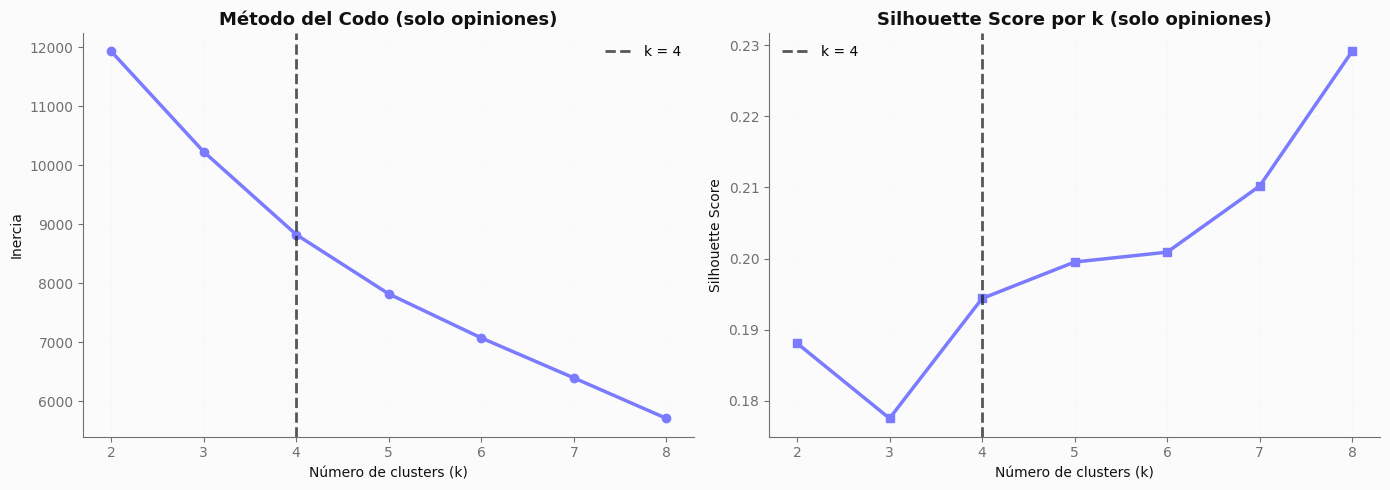

Detalle por k (solo opiniones):
  k=2: inercia=11930.7 | silhouette=0.1881
  k=3: inercia=10228.7 | silhouette=0.1775
  k=4: inercia=8825.1 | silhouette=0.1944 ← elegido
  k=5: inercia=7819.5 | silhouette=0.1995
  k=6: inercia=7073.5 | silhouette=0.2009
  k=7: inercia=6396.4 | silhouette=0.2102
  k=8: inercia=5710.4 | silhouette=0.2292


In [17]:
# Solo variables de opinión
X_opinion = data[opinion_cols]
scaler_op = StandardScaler()
X_op_scaled = scaler_op.fit_transform(X_opinion)

# Elbow + Silhouette
K_range2 = range(2, 9)
inertias2, silhouettes2 = [], []

for k in K_range2:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_op_scaled)
    inertias2.append(km.inertia_)
    silhouettes2.append(silhouette_score(X_op_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_range2), inertias2, marker='o', color=PURPLE, linewidth=2.5)
ax1.axvline(x=4, color=INK, linestyle='--', linewidth=2, alpha=0.7, label='k = 4')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo (solo opiniones)', fontsize=13, fontweight='bold')
ax1.set_xticks(list(K_range2))
ax1.legend(frameon=False)
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_range2), silhouettes2, marker='s', color=PURPLE, linewidth=2.5)
ax2.axvline(x=4, color=INK, linestyle='--', linewidth=2, alpha=0.7, label='k = 4')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por k (solo opiniones)', fontsize=13, fontweight='bold')
ax2.set_xticks(list(K_range2))
ax2.legend(frameon=False)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Detalle por k (solo opiniones):")
for k, iner, sil in zip(K_range2, inertias2, silhouettes2):
    marker = " ← elegido" if k == 4 else ""
    print(f"  k={k}: inercia={iner:.1f} | silhouette={sil:.4f}{marker}")

In [18]:
# K-Means k=4 con solo opiniones
kmeans_op = KMeans(n_clusters=4, random_state=42, n_init=10)
data['cluster_opinion'] = kmeans_op.fit_predict(X_op_scaled)

print(f"Silhouette Score (solo opiniones): {silhouette_score(X_op_scaled, data['cluster_opinion']):.4f}")
print(f"\nDistribución de clusters:")
for cl in range(4):
    n = (data['cluster_opinion'] == cl).sum()
    print(f"  Cluster {cl}: {n} votantes ({n/len(data)*100:.1f}%)")

Silhouette Score (solo opiniones): 0.1944

Distribución de clusters:
  Cluster 0: 871 votantes (23.6%)
  Cluster 1: 892 votantes (24.2%)
  Cluster 2: 956 votantes (25.9%)
  Cluster 3: 970 votantes (26.3%)


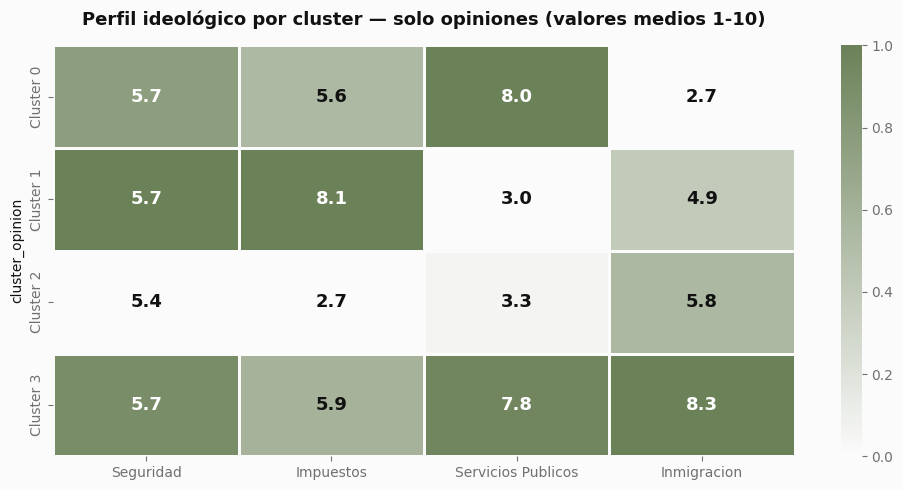

Perfil numérico:
                 seguridad  impuestos  servicios_publicos  inmigracion
cluster_opinion                                                       
0                     5.65       5.63                8.02         2.72
1                     5.74       8.14                3.04         4.92
2                     5.36       2.71                3.28         5.76
3                     5.70       5.92                7.79         8.26


In [19]:
# Perfil ideológico
perfil_op = data.groupby('cluster_opinion')[opinion_cols].mean().round(2)

perfil_op_norm = (perfil_op - perfil_op.min()) / (perfil_op.max() - perfil_op.min())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(perfil_op_norm, annot=perfil_op.values, fmt='.1f', cmap=SEQUENTIAL_GREEN,
            linewidths=1, linecolor=BACKGROUND, ax=ax,
            xticklabels=[c.replace('_', ' ').title() for c in opinion_cols],
            yticklabels=[f'Cluster {i}' for i in range(4)],
            annot_kws={'size': 13, 'weight': 'bold'})
color_annotations(ax, perfil_op_norm.values, threshold=0.6)
ax.set_title('Perfil ideológico por cluster — solo opiniones (valores medios 1-10)',
             fontsize=13, fontweight='bold', color=INK, pad=15)
plt.tight_layout()
plt.show()

print("Perfil numérico:")
print(perfil_op.to_string())

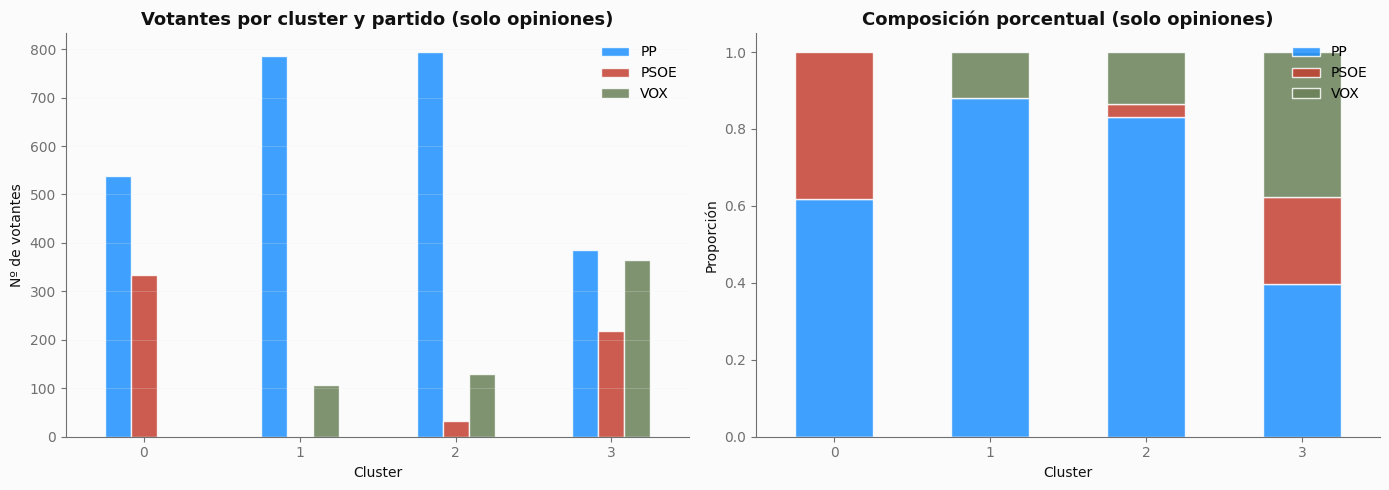

Composición de cada cluster (%):
voto               PP  PSOE   VOX
cluster_opinion                  
0                61.8  38.2   0.0
1                88.0   0.0  12.0
2                83.1   3.3  13.6
3                39.8  22.6  37.6


In [20]:
# Cruce cluster_opinion vs voto
ct_op = pd.crosstab(data['cluster_opinion'], data['voto'])
ct_op_pct = pd.crosstab(data['cluster_opinion'], data['voto'], normalize='index')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ct_op.plot(kind='bar', ax=ax1, color=[colores_partido[p] for p in ct_op.columns],
           edgecolor='white', alpha=0.85)
ax1.set_title('Votantes por cluster y partido (solo opiniones)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Nº de votantes')
ax1.legend(frameon=False)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.grid(True, alpha=0.3, axis='y')

ct_op_pct.plot(kind='bar', stacked=True, ax=ax2,
               color=[colores_partido[p] for p in ct_op_pct.columns],
               edgecolor='white', alpha=0.85)
ax2.set_title('Composición porcentual (solo opiniones)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Proporción')
ax2.legend(frameon=False)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("Composición de cada cluster (%):")
print((ct_op_pct * 100).round(1).to_string())

### Lectura de los perfiles (solo opiniones)

**Cluster 0 — Perfil pro-servicios públicos, anti-inmigración:**
Alta puntuación en servicios públicos (~8.0) y baja en inmigración (~2.7). Concentra votantes de **PSOE** (38%) junto con PP (62%). Ningún votante de VOX — es el único cluster que lo excluye completamente.

**Cluster 1 — Perfil conservador fiscal:**
Puntuación alta en impuestos (~8.1) y baja en servicios públicos (~3.0). Dominado por **PP** (88%) con algo de VOX (12%) y ningún votante de PSOE.

**Cluster 2 — Perfil anti-impuestos:**
Baja puntuación tanto en impuestos (~2.7) como en servicios públicos (~3.3). Dominado por **PP** (83%) con algo de VOX (14%).

**Cluster 3 — Perfil seguridad + inmigración:**
Alta puntuación en servicios públicos (~7.8) e inmigración (~8.3). El cluster más diverso: PP (40%), **VOX** (38%) y PSOE (23%).

## 9. Conclusiones e insights

### ¿Funciona K-Means para segmentar votantes?

**Sí, pero solo si se eligen las variables correctas.** Con todas las variables (demográficas + categóricas codificadas), K-Means se ancla a las separaciones nítidas del One-Hot Encoding y produce clusters demográficos sin valor político. Con solo las 4 variables de opinión, los clusters reflejan perfiles ideológicos reales.

Este análisis demuestra que **incluir más variables puede empeorar el modelo**.

El silhouette de 0.194 indica solapamiento entre clusters. Pero **la gente no se divide en bloques ideológicos perfectos** — un votante de PP puede opinar igual que uno de PSOE en servicios públicos y distinto en inmigración. Las fronteras borrosas reflejan la realidad política.

### ¿Qué variables separan más?

1. **Servicios públicos** e **inmigración** son los dos ejes con mayor poder de separación.
2. **Impuestos** diferencia el Cluster 1 del 2, pero ambos votan mayoritariamente PP.
3. **Seguridad** solo es discriminante combinada con inmigración alta (perfil VOX).

### Lo que le diría a un partido político

- **A PSOE:** vuestros votantes se concentran donde servicios públicos puntúa alto e inmigración puntúa bajo.
- **A VOX:** vuestros votantes aparecen donde seguridad e inmigración puntúan alto simultáneamente. K-Means lo detecta sin que nadie se lo diga.
- **A PP:** vuestros votantes están en todos los clusters. Fortaleza (amplia base) y riesgo (perfiles muy distintos bajo la misma sigla).